<a href="https://colab.research.google.com/github/solenn-tl/phd-cadastre-ancien/blob/main/mistral/ocr/test_data_extraction_mistral_ocr4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extract Data from Documents via Annotations

---

## Annotations for Structured Outputs and Data Extraction
In this cookbook, we will explore the basics of Annotations and to achieve structured outputs fueled by our OCR model.

You may want to do this in case current vision models are not powerful enough, hence enhancing their vision OCR capabilities with the OCR model to achieve better structured data extraction.


## What are Annotations?

Mistral Document AI API adds two annotation functionalities:
- `document_annotation`: returns the annotation of the entire document based on the input schema.
- `box_annotation`: gives you the annotation of the bboxes extracted by the OCR model (charts/ figures etc) based on user requirement. The user may ask to describe/caption the figure for instance.

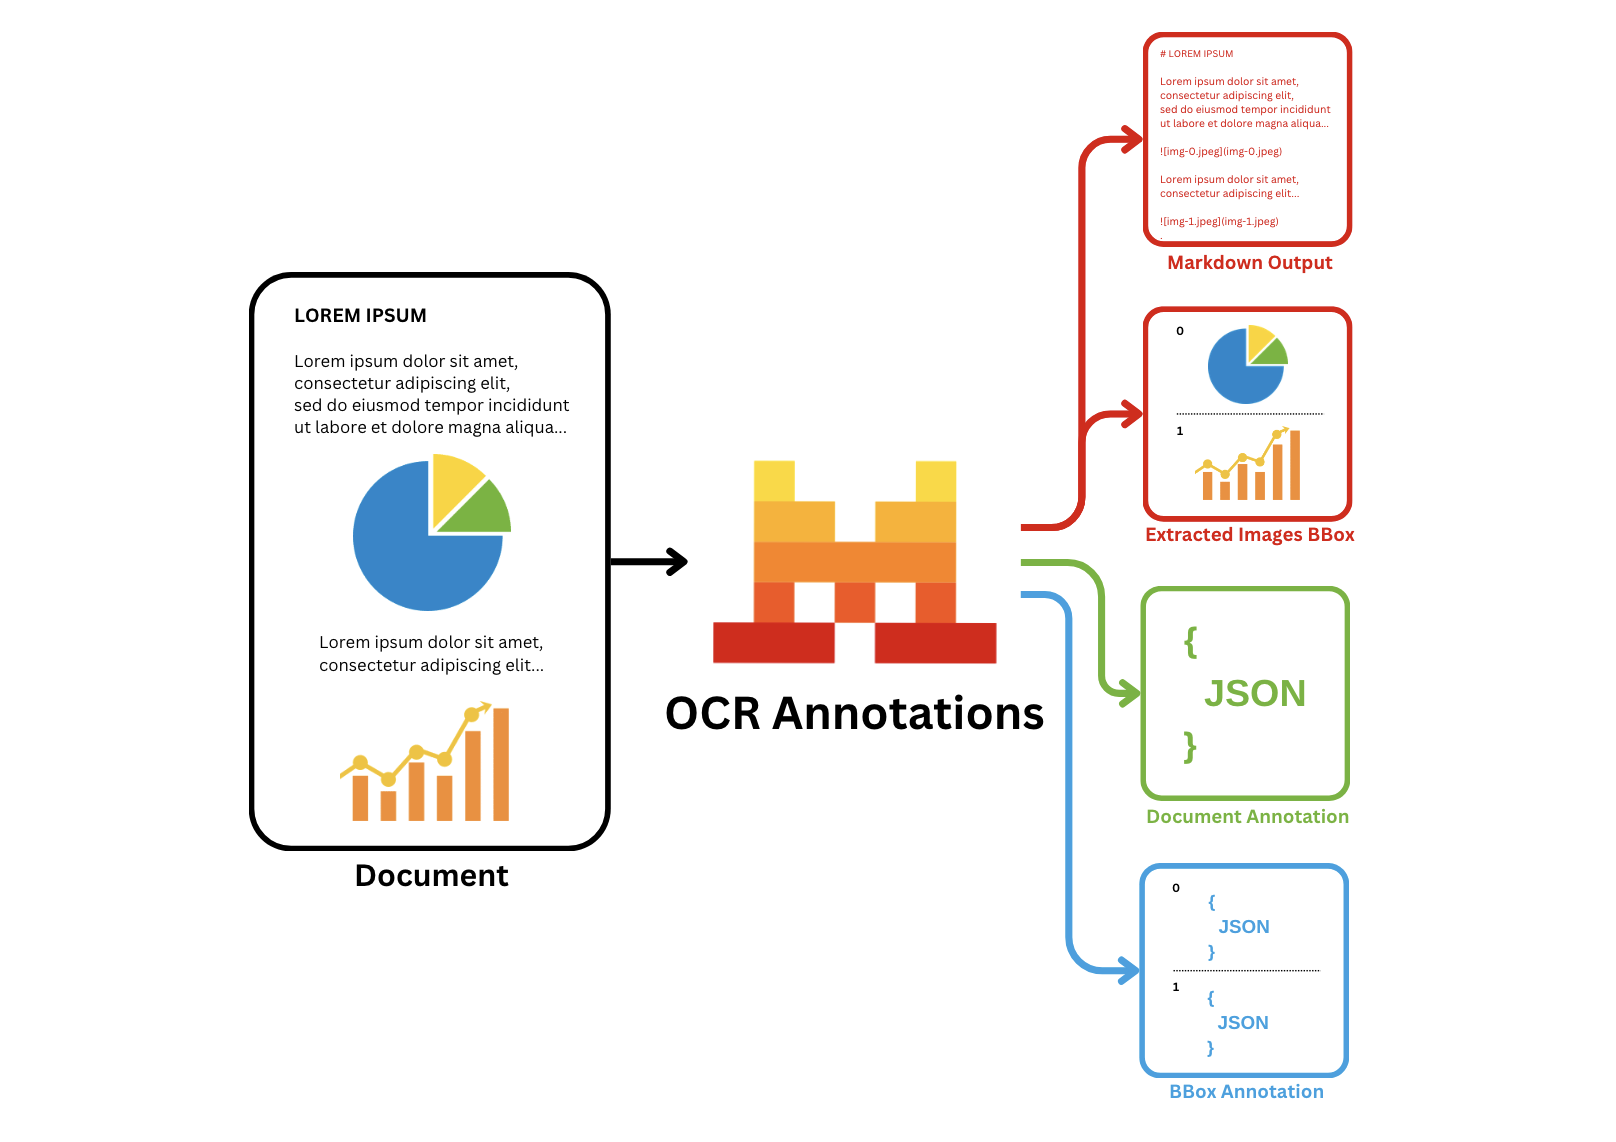

Learn more about Annotations [here](https://docs.mistral.ai/capabilities/OCR/annotations/).

## Setup

First, let's install `mistralai` and download the required files.

In [1]:
%%capture
!pip install mistralai

### Download PDF

In [2]:
%%capture
!wget https://raw.githubusercontent.com/mistralai/cookbook/refs/heads/main/mistral/ocr/mistral7b.pdf

### Create Client

We will need to set up our client. You can create an API key on [AI Studio](https://console.mistral.ai/api-keys/).

In [123]:
# Initialize Mistral client with API key
from mistralai.client import Mistral

api_key = "WpOZKwP5iLYjmbD0HaGBnVmcQsZVzQdS" # Replace with your API key
client = Mistral(api_key=api_key)

Since the release of OCR4, we can view the result with the following. When `confidence_scores_granularity="word"` is set, words are color-coded by OCR confidence:

- **Red**: &lt; 60%
- **Orange**: 60–80%
- **Yellow**: 80–95%
- **White**: 95–100%

Hover over a word to see its exact confidence score.



## Mistral OCR with Annotations
First, we need to create our Annotation Formats, for that we advise make use of `pydantic`.  
For this example, we will extract the image type and a description of each bbox; as well as the language, authors and a summary of the full document.

In [124]:
from PIL import Image
import urllib.request

path = "https://www.geneoweb.fr/wp-content/uploads/2023/11/cadastre-etat-des-sections.jpg"
urllib.request.urlretrieve(path, "cadastre-etat-des-sections.jpg")
im = Image.open("cadastre-etat-des-sections.jpg")
im.info

{'jfif': 257,
 'jfif_version': (1, 1),
 'dpi': (96, 96),
 'jfif_unit': 1,
 'jfif_density': (96, 96),
 'progressive': 1,
 'progression': 1}

In [125]:
from pydantic import BaseModel, Field
from enum import Enum

class ImageType(str, Enum):
    #GRAPH = "graph"
    #TEXT = "text"
    TABLE = "table"
    #IMAGE = "image"

class Image(BaseModel):
    image_type: ImageType = Field(..., description="The image is a single page containing a table with a printed header and manuscript rows.")
    description: str = Field(..., description="The image is a digitized 19th-century land registry record table. Each row describe a land plot.")

class Document(BaseModel):
    language: str = Field(..., description="fr")
    summary: str = Field(..., description="The document is a table describing the land plots of a city.")
    authors: list[str] = Field(..., description="Fiscal administration of the 19th century.")


Now with our pydantic models created for our Annotations, we can call our OCR endpoint.  
The objective is to Annotate and Extract information from our document and the bbox/images detected.

In [127]:
from mistralai.extra import response_format_from_pydantic_model
import json

# OCR Call with Annotations
annotations_response = client.ocr.process(
    model="mistral-ocr-latest",
    pages=list(range(8)), # Document Annotations has a limit of 8 pages, we recommend spliting your documents when using it; bbox annotations does not have the same limit
    document={
        "type": "image_url",
        "image_url": f"{path}"
    },
    #table_format='markdown',
    #extract_header=True,
    include_blocks=True,
    include_image_base64=True,
    confidence_scores_granularity="word",
    bbox_annotation_format=response_format_from_pydantic_model(Image),
    document_annotation_format=response_format_from_pydantic_model(Document),
  )

# Convert response to JSON format
response_dict = json.loads(annotations_response.model_dump_json())

print(json.dumps(response_dict, indent=4))

{
    "pages": [
        {
            "index": 0,
            "markdown": "|  NOMS, PR\u00c9NOMS, PROFESSIONS ET DEMEURES des propri\u00e9taires. | NUM\u00c9ROS du plan. | CANTONS OU LIEUX DITS. | NATURE DE PROPRI\u00c9T\u00c9S. | CONTENANCE. | CLASSES. | REVENU.  |\n| --- | --- | --- | --- | --- | --- | --- |\n|  Idiant Dominici\u00e9 \u00e0 St. Palais Le m\u00eame Le m\u00eame | 1 | Bascagua Siqueira | Future | 12 20 | 3 | \"09  |\n|   |  2 | I dem. | Future | 2 96 40 | 2 | 4.15  |\n|   |  3 | I dem. | Future | 23 60 | 3 | \"16  |\n|  Borda Samacels Notaire \u00e0 St. Fridgues Chabure (Armand) \u00e0 Malparraute | 4 | Bascagua | Future | 1 37 70 | 2 | 1.93  |\n|   |  5 | Omaha | Pr\u00e9 | 40 20 | 3 | 1.45  |\n|  Le m\u00eame | 6 | Omaha Siqueira | Pr\u00e9 future | 12 50 | 3 | \"29  |\n|  Le m\u00eame | 7 | Omaha | Pr\u00e9 | 24 00 | 3 | \"86  |",
            "images": [],
            "dimensions": {
                "dpi": 200,
                "height": 625,
                "width"

Let's print the Annotations only!

In [128]:
print("Document Annotation:\n", annotations_response.pages[0].blocks)
print("\nBBox/Images:")
for page in annotations_response.pages:
    for image in page.images:
        print("\nImage", image.id)
        print("Location:")
        print(" - top_left_x:", image.top_left_x)
        print(" - top_left_y:", image.top_left_y)
        print(" - bottom_right_x:", image.bottom_right_x)
        print(" - bottom_right_y:", image.bottom_right_y)
        print("BBox/Image Annotation:\n", image.document_annotation)

Document Annotation:
 [OCRTableBlock(top_left_x=31, top_left_y=30, bottom_right_x=1378, bottom_right_y=624, content='|  NOMS, PRÉNOMS, PROFESSIONS ET DEMEURES des propriétaires. | NUMÉROS du plan. | CANTONS OU LIEUX DITS. | NATURE DE PROPRIÉTÉS. | CONTENANCE. | CLASSES. | REVENU.  |\n| --- | --- | --- | --- | --- | --- | --- |\n|  Idiant Dominicié à St. Palais Le même Le même | 1 | Bascagua Siqueira | Future | 12 20 | 3 | "09  |\n|   |  2 | I dem. | Future | 2 96 40 | 2 | 4.15  |\n|   |  3 | I dem. | Future | 23 60 | 3 | "16  |\n|  Borda Samacels Notaire à St. Fridgues Chabure (Armand) à Malparraute | 4 | Bascagua | Future | 1 37 70 | 2 | 1.93  |\n|   |  5 | Omaha | Pré | 40 20 | 3 | 1.45  |\n|  Le même | 6 | Omaha Siqueira | Pré future | 12 50 | 3 | "29  |\n|  Le même | 7 | Omaha | Pré | 24 00 | 3 | "86  |', type='table', table_id=None)]

BBox/Images:


In [129]:
#Display the bbox coordinates on the image
from IPython.display import Image, display
from PIL import Image as PILImage, ImageDraw
import urllib

def retrieve_bboxes_image(annotations_response, image_index):
  pages = annotations_response.pages
  page = pages[image_index]
  blocks = page.blocks
  for block in blocks:
    top_left_x = block.top_left_x
    top_left_y = block.top_left_y
    bottom_right_x = block.bottom_right_x
    bottom_right_y = block.bottom_right_y
    return top_left_x, top_left_y, bottom_right_x, bottom_right_y

def display_bboxes_on_image(image_path, top_left_x, top_left_y, bottom_right_x, bottom_right_y):
  img = PIL.Image.open(image_path)
  draw = ImageDraw.Draw(img)
  draw.rectangle([(top_left_x, top_left_y), (bottom_right_x, bottom_right_y)], outline="red")
  display(img)


In [130]:
top_left_x, top_left_y, bottom_right_x, bottom_right_y = retrieve_bboxes_image(annotations_response, 0)

## Full Document with Annotation
For reference, let's do the same but including the bbox images.

Now, we will display the full document with the OCR content and the annotation in bold:
- Document Annotation at the start of the document.
- BBox Annotation at below each bbox/image extracted.

In [131]:
def replace_images_in_markdown_annotated(markdown_str: str, images_dict: dict) -> str:
    """
    Replace image placeholders in markdown with base64-encoded images and their annotation.

    Args:
        markdown_str: Markdown text containing image placeholders
        images_dict: Dictionary mapping image IDs to base64 strings

    Returns:
        Markdown text with images replaced by base64 data and their annotation
    """
    for img_name, data in images_dict.items():
        markdown_str = markdown_str.replace(
            f"![{img_name}]({img_name})", f"![{img_name}]({data['image']})\n\n**{data['annotation']}**"
        )
    return markdown_str

def get_combined_markdown_annotated(ocr_response: OCRResponse) -> str:
    """
    Combine OCR text, annotation and images into a single markdown document.

    Args:
        ocr_response: Response from OCR processing containing text and images

    Returns:
        Combined markdown string with embedded images and their annotation
    """
    markdowns: list[str] = ["**" + ocr_response.document_annotation + "**"]
    # Extract images from page
    for page in ocr_response.pages:
        image_data = {}
        for img in page.images:
            image_data[img.id] = {"image":img.image_base64, "annotation": img.image_annotation}
        # Replace image placeholders with actual images
        markdowns.append(replace_images_in_markdown_annotated(page.markdown, image_data))

    return "\n\n".join(markdowns)

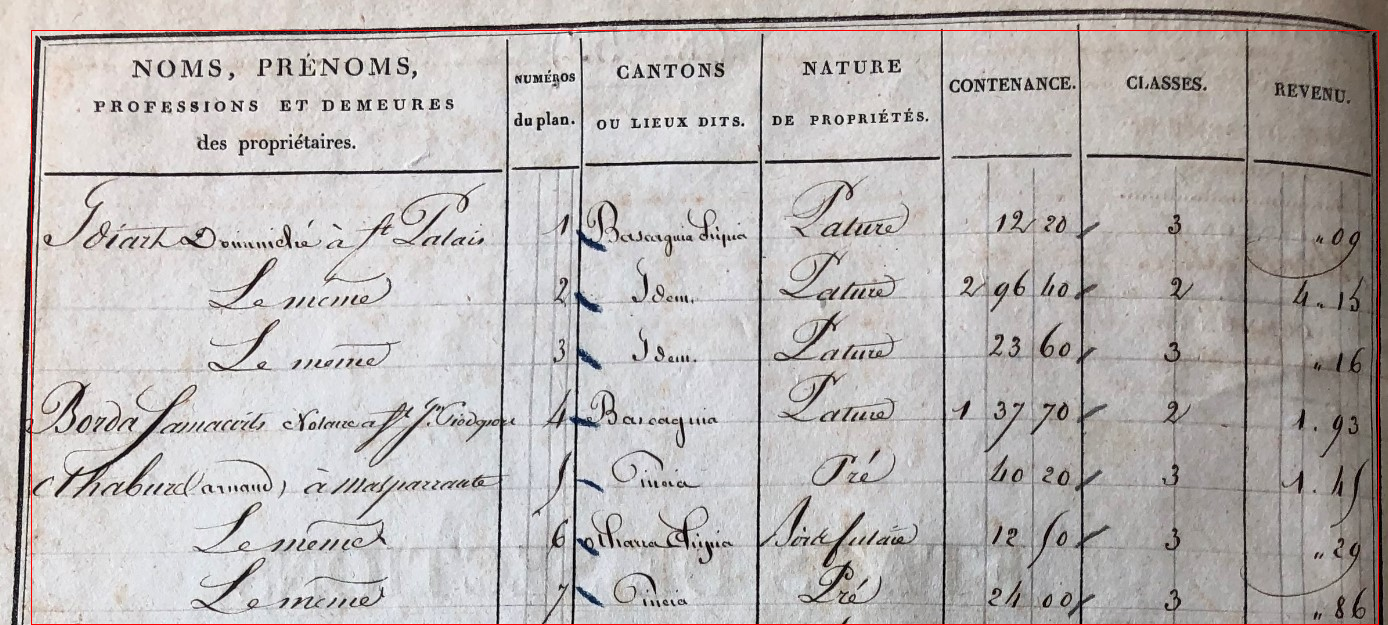

In [132]:
display_bboxes_on_image("cadastre-etat-des-sections.jpg", top_left_x, top_left_y, bottom_right_x, bottom_right_y)

In [133]:
# Display combined markdowns and images
display(Markdown(get_combined_markdown_annotated(annotations_response)))

**{"language": "fr", "summary": "Le document est un tableau détaillé des parcelles de terrain d'une ville, incluant les noms et professions des propriétaires, les numéros des parcelles sur le plan, les cantons ou lieux-dits, la nature des propriétés (futures ou prairies), leur contenance en ares, leur classe, et leur revenu annuel estimé. Les données sont organisées par propriétaire, avec des entrées pour des parcelles situées dans des zones comme Bascagua, Siqueira, ou Omaha.", "authors": ["Fiscal administration of the 19th century"]}**

|  NOMS, PRÉNOMS, PROFESSIONS ET DEMEURES des propriétaires. | NUMÉROS du plan. | CANTONS OU LIEUX DITS. | NATURE DE PROPRIÉTÉS. | CONTENANCE. | CLASSES. | REVENU.  |
| --- | --- | --- | --- | --- | --- | --- |
|  Idiant Dominicié à St. Palais Le même Le même | 1 | Bascagua Siqueira | Future | 12 20 | 3 | "09  |
|   |  2 | I dem. | Future | 2 96 40 | 2 | 4.15  |
|   |  3 | I dem. | Future | 23 60 | 3 | "16  |
|  Borda Samacels Notaire à St. Fridgues Chabure (Armand) à Malparraute | 4 | Bascagua | Future | 1 37 70 | 2 | 1.93  |
|   |  5 | Omaha | Pré | 40 20 | 3 | 1.45  |
|  Le même | 6 | Omaha Siqueira | Pré future | 12 50 | 3 | "29  |
|  Le même | 7 | Omaha | Pré | 24 00 | 3 | "86  |